In [2]:
import pandas as pd
# !pip install numpy-financial
import numpy_financial as npf
import matplotlib.pyplot as plt
import os
import seaborn as sns
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-whitegrid')

pd.options.display.float_format = '{:,.2f}'.format



               UTILITY SCALE SOLAR FINANCIAL MODEL               

PROJECT ASSUMPTIONS
            Parameter         Value         Unit
          Capacity_MW         50.00           MW
         CAPEX_per_MW 35,000,000.00   INR_per_MW
         OPEX_percent          0.01      decimal
          Tariff_base          3.50  INR_per_kWh
           Tariff_low          3.00  INR_per_kWh
          Tariff_high          4.00  INR_per_kWh
      Capacity_factor          0.19      decimal
          Degradation          0.01      decimal
   Project_life_years         25.00        years
Discount_rate_decimal          0.10      decimal
      Emission_factor          0.90 tCO2_per_MWh
       Hours_per_year      8,760.00        hours

PROJECT COST STRUCTURE
Total CAPEX: ₹1,750,000,000
Annual OPEX: ₹26,250,000

ENERGY PRODUCTION ANALYSIS
Year 1 Energy: 83,220 MWh
Degradation Rate: 0.50%
 Year  Energy_MWh
    1   83,220.00
    2   82,803.90
    3   82,389.88
    4   81,977.93
    5   81,568.04


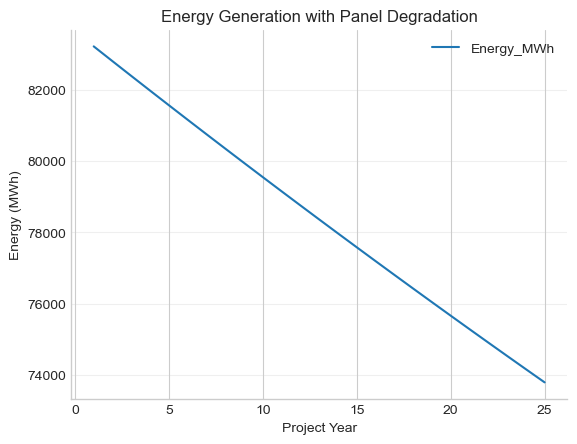

Insight: Output declines gradually due to module degradation.

REVENUE & CASHFLOW MODEL
Insight: Stable revenue driven by fixed tariff assumption.

FINANCIAL PERFORMANCE
NPV: ₹559,853,660
IRR: 14.11%
Payback: 7 years
Discounted Payback: 12 years
Insight: Payback achieved in year 7


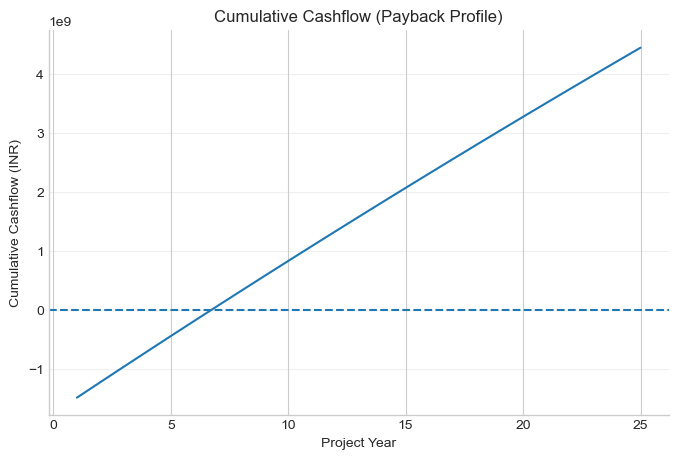


COST EFFICIENCY ANALYSIS
Tariff: ₹3.5
LCOE: ₹2.73/kWh
Project economically viable

ESG IMPACT ANALYSIS
Total CO2 avoided: 1,764,295 tons
CO2 avoided per MW: 35,286 tons


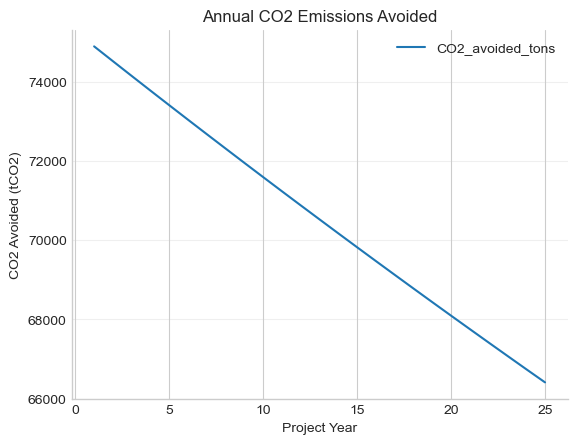


SCENARIO ANALYSIS

 Tariff Scenario Tariff NPV_INR_million IRR_percent
     Low Tariff  ₹3.00         ₹195.8M      11.47%
      Base Case  ₹3.50         ₹559.9M      14.11%
    High Tariff  ₹4.00         ₹923.9M      16.65% 

Insight: Tariff is the most sensitive driver of project returns.


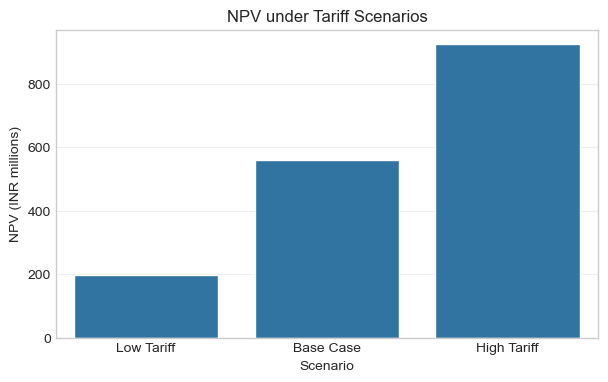

Insight: Project viability becomes marginal below ~₹3/kWh tariff.

SENSITIVITY ANALYSIS


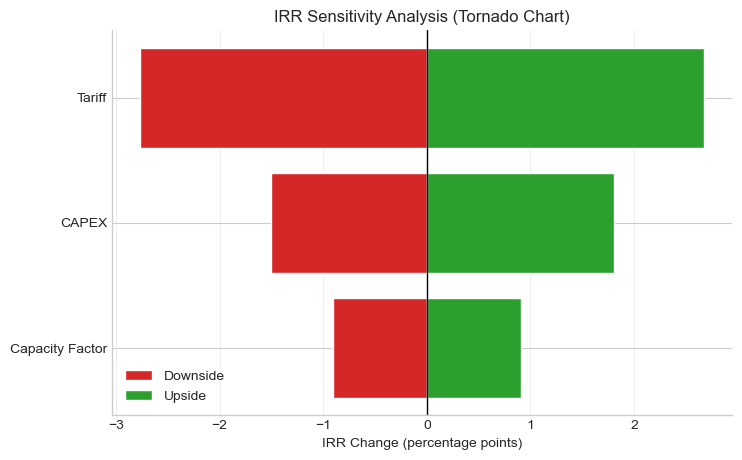


        Variable Change    Low   High Impact
Capacity Factor    ±5% 13.20% 15.01%   0.91
          CAPEX   ±10% 12.60% 15.91%   1.80
         Tariff   ±15% 11.34% 16.78%   2.77 

Sensitivity Insights:
• Base IRR: 14.11%
• Tariff shows highest sensitivity due to revenue exposure
• CAPEX impact moderate due to upfront cost structure
• Capacity factor impact lower due to limited variability range
• 15% tariff reduction reduces IRR by 2.77 percentage points
• Project remains viable under downside assumptions


                 SOLAR PROJECT INVESTMENT SUMMARY                
Project Capacity                               50.0 MW
NPV                                    ₹559,853,660 
IRR                                           14.11 %
Payback Period                                    7 years
Discounted Payback                               12 years
LCOE                                          ₹2.73 per kWh
Total CO2 avoided                         1,764,295 tons
CO2 avoided per MW        

In [6]:
# ============================================================
# Helper formatting functions (REPORT STRUCTURE)
# ============================================================

def section(title):
    print("\n" + "="*60)
    print(title.upper())
    print("="*60)

def subsection(title):
    print("\n" + "-"*40)
    print(title)
    print("-"*40)

def banner(title):

    print("\n")
    print("="*65)
    print(title.center(65))
    print("="*65)


def metric(label,value,unit=""):

    print(f"{label:<35} {value:>15} {unit}")


banner("UTILITY SCALE SOLAR FINANCIAL MODEL")

# ============================================================
# Load assumptions
# ============================================================

section("Project Assumptions")

assumptions_df = pd.read_csv("data/assumptions.csv")

assumptions = dict(zip(
    assumptions_df["Parameter"],
    assumptions_df["Value"].astype(float)
))

assump_display = assumptions_df.copy()

assump_display["Value"] = assump_display[
"Value"
].map("{:,.2f}".format)

print(assump_display.to_string(index=False))


# ============================================================
# Assign variables
# ============================================================

capacity = assumptions['Capacity_MW']
capex_per_mw = assumptions['CAPEX_per_MW']
opex_percent = assumptions['OPEX_percent']
tariff = assumptions['Tariff_base']
capacity_factor = assumptions['Capacity_factor']
degradation = assumptions['Degradation']
project_life = int(assumptions['Project_life_years'])
discount_rate = assumptions['Discount_rate_decimal']
emission_factor = assumptions['Emission_factor']
hours = assumptions['Hours_per_year']


# ============================================================
# Cost Structure
# ============================================================

section("Project Cost Structure")

total_capex = capacity * capex_per_mw
annual_opex = round(total_capex * opex_percent,0)

print(f"Total CAPEX: ₹{total_capex:,.0f}")
print(f"Annual OPEX: ₹{annual_opex:,.0f}")


# ============================================================
# Energy Production Model
# ============================================================

section("Energy Production Analysis")

annual_energy_year1 = capacity * capacity_factor * hours

print(f"Year 1 Energy: {annual_energy_year1:,.0f} MWh")
print(f"Degradation Rate: {degradation*100:.2f}%")


yearly_energy = []

for year in range(1, project_life + 1):

    energy = round(
        annual_energy_year1*((1-degradation)**(year-1)),2
    )

    yearly_energy.append(energy)


years = list(range(1, project_life + 1))

energy_df = pd.DataFrame({

    "Year":years,
    "Energy_MWh":yearly_energy

})

print(
energy_df[
["Year","Energy_MWh"]
].head().to_string(index=False)
)

energy_df.plot(

x="Year",
y="Energy_MWh",
title="Energy Generation with Panel Degradation"

)
plt.xlabel("Project Year")
plt.ylabel("Energy (MWh)")

plt.grid(axis='y',alpha=0.3)

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

print("Insight: Output declines gradually due to module degradation.")

# ============================================================
# Revenue & Cashflow Model
# ============================================================

section("Revenue & Cashflow Model")

energy_df["Revenue_INR"] = (
    energy_df["Energy_MWh"]*tariff*1000
).round(0)

energy_df["OPEX_INR"] = annual_opex

energy_df["Cashflow_INR"] = (
    energy_df["Revenue_INR"]-
    energy_df["OPEX_INR"]
).round(0)

print("Insight: Stable revenue driven by fixed tariff assumption.")


initial_investment = -total_capex

cashflows = [
    initial_investment
] + energy_df["Cashflow_INR"].tolist()

energy_df["EBITDA_INR"]=energy_df["Cashflow_INR"]

energy_df["Cumulative_Cashflow"]=(
energy_df["Cashflow_INR"].cumsum()-total_capex
).round(0)


energy_df["Discounted_Cashflow"]=[

round(cf/((1+discount_rate)**year),0)

for year,cf in enumerate(
energy_df["Cashflow_INR"],start=1)

]

energy_df["Cumulative_Discounted_CF"]=(energy_df["Discounted_Cashflow"].cumsum()-total_capex).round(0)

# ============================================================
# Financial Metrics
# ============================================================

section("Financial Performance")

npv = 0

for year,cf in enumerate(cashflows):

    npv += cf/((1+discount_rate)**year)


irr = npf.irr(cashflows)


# Payback

cumulative = 0
payback_year=None

for year,cf in enumerate(cashflows):

    cumulative+=cf

    if cumulative>0 and payback_year is None:

        payback_year=year


# Discounted Payback

discounted_cumulative=0
discounted_payback=None

for year,cf in enumerate(cashflows):

    discounted_cf=cf/((1+discount_rate)**year)

    discounted_cumulative+=discounted_cf

    if discounted_cumulative>0 and discounted_payback is None:

        discounted_payback=year


print(f"NPV: ₹{npv:,.0f}")
print(f"IRR: {irr*100:.2f}%")
print(f"Payback: {payback_year} years")
print(f"Discounted Payback: {discounted_payback} years")

print("Insight: Payback achieved in year",payback_year)

fig, ax = plt.subplots(figsize=(8,5))

energy_df.plot(
    x="Year",
    y="Cumulative_Cashflow",
    ax=ax,
    legend=False
)

plt.axhline(0,linestyle="--")

plt.title("Cumulative Cashflow (Payback Profile)")

plt.xlabel("Project Year")
plt.ylabel("Cumulative Cashflow (INR)")

plt.grid(axis='y',alpha=0.3)

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.show()

# ============================================================
# LCOE Calculation
# ============================================================

section("Cost Efficiency Analysis")

# Levelized cost:

# LCOE = Total lifetime cost / Total lifetime energy

discounted_energy=[]

for year,energy in enumerate(yearly_energy,start=1):

    de=energy/((1+discount_rate)**year)

    discounted_energy.append(de)

npv_energy=sum(discounted_energy)


discounted_opex=[]

for year in range(1,project_life+1):

    dopex=annual_opex/((1+discount_rate)**year)

    discounted_opex.append(dopex)


npv_opex=sum(discounted_opex)

total_cost_npv=total_capex+npv_opex


lcoe=total_cost_npv/(npv_energy*1000)

print(f"Tariff: ₹{tariff}")
print(f"LCOE: ₹{lcoe:.2f}/kWh")

if lcoe<tariff:

    print("Project economically viable")

else:

    print("Project not viable")


# ============================================================
# ESG Impact
# ============================================================

section("ESG Impact Analysis")

energy_df["CO2_avoided_tons"]=(
    energy_df["Energy_MWh"]*emission_factor
).round(0)

total_co2_avoided=energy_df["CO2_avoided_tons"].sum()

co2_per_mw=total_co2_avoided/capacity


print(f"Total CO2 avoided: {total_co2_avoided:,.0f} tons")

print(f"CO2 avoided per MW: {co2_per_mw:,.0f} tons")

energy_df.plot(

x="Year",
y="CO2_avoided_tons",
title="Annual CO2 Emissions Avoided"

)
plt.xlabel("Project Year")
plt.ylabel("CO2 Avoided (tCO2)")

plt.grid(axis='y',alpha=0.3)

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

# ============================================================
# Additional Columns
# ============================================================


energy_df=energy_df[

[
"Year",
"Energy_MWh",
"Revenue_INR",
"OPEX_INR",
"EBITDA_INR",
"Cashflow_INR",
"Cumulative_Cashflow",
"Discounted_Cashflow",
"Cumulative_Discounted_CF",
"CO2_avoided_tons"
]
]


# ============================================================
# Scenario Analysis
# ============================================================

section("Scenario Analysis")

# Sensitivity ranges based on typical renewable project risk ranges:
# Tariff: merchant/PPA volatility
# CAPEX: EPC cost variability
# Capacity factor: resource uncertainty

scenarios = {

"Low Tariff":assumptions['Tariff_low'],

"Base Case":assumptions['Tariff_base'],

"High Tariff":assumptions['Tariff_high']

}


scenario_results = []

for name,scenario_tariff in scenarios.items():

    # Recalculate revenue
    
    scenario_revenue = [
        energy * scenario_tariff * 1000
        for energy in yearly_energy
    ]
    
    
    # Recalculate cashflows
    
    scenario_cashflows = [
        initial_investment
    ] + [
        round(rev - annual_opex,0)
        for rev in scenario_revenue
    ]
    
    
    # NPV
    
    scenario_npv = 0
    
    for year,cf in enumerate(scenario_cashflows):
        
        scenario_npv += cf/((1+discount_rate)**year)
    
    
    # IRR
    
    scenario_irr = npf.irr(scenario_cashflows)
    
    
    scenario_results.append({

        "Tariff Scenario":name,

        "Tariff":scenario_tariff,

        "NPV_INR_million":round(scenario_npv/1_000_000,1),

        "IRR_percent":round(scenario_irr*100,2)

    })


scenario_df = pd.DataFrame(scenario_results)

scenario_display = scenario_df.copy()

scenario_display["Tariff"] = scenario_display[
"Tariff"
].map("₹{:.2f}".format)

scenario_display["NPV_INR_million"] = scenario_display[
"NPV_INR_million"
].map("₹{:,.1f}M".format)

scenario_display["IRR_percent"] = scenario_display[
"IRR_percent"
].map("{:.2f}%".format)

print("\n",scenario_display[["Tariff Scenario","Tariff","NPV_INR_million","IRR_percent"]
].to_string(index=False),"\n")

print("Insight: Tariff is the most sensitive driver of project returns.")

plt.figure(figsize=(7,4))

sns.barplot(
data=scenario_df,
x="Tariff Scenario",
y="NPV_INR_million"
)

plt.title("NPV under Tariff Scenarios")

plt.grid(axis='y',alpha=0.3)

plt.xlabel("Scenario")
plt.ylabel("NPV (INR millions)")

plt.show()


print("Insight: Project viability becomes marginal below ~₹3/kWh tariff.")

# ============================================================
# Sensitivity Analysis
# ============================================================

section("Sensitivity Analysis")

# Sensitivity ranges based on typical renewable project risk ranges:
# Tariff: merchant/PPA volatility
# CAPEX: EPC cost variability
# Capacity factor: resource uncertainty

base_irr = irr*100

sensitivities = []

variables = {

"Tariff":[tariff*0.85, tariff*1.15],          # ±15%

"CAPEX":[capex_per_mw*1.10, capex_per_mw*0.90],  # ±10%

"Capacity Factor":[capacity_factor*0.95, capacity_factor*1.05]  # ±5%

}

sens_labels = {

"Tariff":"±15%",

"CAPEX":"±10%",

"Capacity Factor":"±5%"

}

for var,(low,high) in variables.items():
    
    irr_values = []
    
    for value in [low,high]:
        
        if var=="Tariff":
            test_tariff=value
            test_capex=capex_per_mw
            test_cf=capacity_factor
            
        elif var=="CAPEX":
            test_tariff=tariff
            test_capex=value
            test_cf=capacity_factor
            
        else:
            test_tariff=tariff
            test_capex=capex_per_mw
            test_cf=value
        
        test_capex_total=capacity*test_capex
        
        test_energy = [
            annual_energy_year1*((1-degradation)**(y-1))*test_cf/capacity_factor
            for y in range(1,project_life+1)
        ]
        
        test_revenue=[
            energy*test_tariff*1000
            for energy in test_energy
        ]
        
        test_cashflows=[
            -test_capex_total
        ] + [
            rev-annual_opex
            for rev in test_revenue
        ]
        
        test_irr=npf.irr(test_cashflows)*100
        
        irr_values.append(round(test_irr,2))
    
    
    sensitivities.append({

        "Variable":var,

        "Change":sens_labels[var],

        "Low":irr_values[0],

        "High":irr_values[1]

    })


sens_df=pd.DataFrame(sensitivities)

# ============================================================
# Tornado Calculations
# ============================================================

sens_df["Low Impact"] = sens_df["Low"] - base_irr

sens_df["High Impact"] = sens_df["High"] - base_irr

sens_df["Impact"] = sens_df[
["Low Impact","High Impact"]
].abs().max(axis=1)

sens_df = sens_df.sort_values("Impact")

# ============================================================
# Tornado Chart
# ============================================================

fig, ax = plt.subplots(figsize=(8,5))

ax.barh(
sens_df["Variable"],
sens_df["Low Impact"],
color="#D62728",
label="Downside"
)

ax.barh(
sens_df["Variable"],
sens_df["High Impact"],
color="#2CA02C",
label="Upside"
)

ax.axvline(
0,
color="black",
linewidth=1
)

ax.set_title("IRR Sensitivity Analysis (Tornado Chart)")

ax.set_xlabel("IRR Change (percentage points)")

ax.grid(axis='x',alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()

plt.show()

# Add labels

for i,row in sens_df.iterrows():

    ax.text(
        row["Low Impact"]-0.05,
        i,
        f"{row['Low Impact']:.2f}",
        va='center',
        ha='right'
    )

    ax.text(
        row["High Impact"]+0.05,
        i,
        f"{row['High Impact']:.2f}",
        va='center'
    )

# ============================================================
# Display Sensitivity Table
# ============================================================

sens_display = sens_df.copy()

sens_display["Low"] = sens_display["Low"].map("{:.2f}%".format)

sens_display["High"] = sens_display["High"].map("{:.2f}%".format)

sens_display["Impact"] = sens_display["Impact"].map("{:.2f}".format)

print("\n",sens_display[
["Variable","Change","Low","High","Impact"]
].to_string(index=False),"\n")

# ============================================================
# Sensitivity Insights
# ============================================================

irr_drop = abs(
sens_df.loc[
sens_df["Variable"]=="Tariff",
"Low Impact"
].values[0]
)

print("Sensitivity Insights:")

print(f"• Base IRR: {base_irr:.2f}%")

print("• Tariff shows highest sensitivity due to revenue exposure")

print("• CAPEX impact moderate due to upfront cost structure")

print("• Capacity factor impact lower due to limited variability range")

print(f"• 15% tariff reduction reduces IRR by {irr_drop:.2f} percentage points")

print("• Project remains viable under downside assumptions")

# ============================================================
# Investment Summary Table
# ============================================================

banner("SOLAR PROJECT INVESTMENT SUMMARY")

metric("Project Capacity",f"{capacity}","MW")

metric("NPV",f"₹{npv:,.0f}")

metric("IRR",f"{irr*100:.2f}","%")

metric("Payback Period",payback_year,"years")

metric("Discounted Payback",discounted_payback,"years")

metric("LCOE",f"₹{lcoe:.2f}","per kWh")

metric("Total CO2 avoided",f"{total_co2_avoided:,.0f}","tons")

metric("CO2 avoided per MW",f"{co2_per_mw:,.0f}","tons")


banner("INVESTMENT VERDICT")

if irr > 12 and lcoe < tariff:

    print("Project meets investment criteria.")
    
    print("Returns exceed typical solar hurdle rates.")
    
else:

    print("Project requires further review.")
    

print("\nKey Strengths:")

print("• Strong unit economics")

print("• Positive NPV")

print("• ESG positive asset")

print("• Predictable cashflows")


print("\nKey Risks:")

print("• Tariff sensitivity")

print("• Generation variability")

print("• Long payback duration")


# ============================================================
# Key Insights
# ============================================================

section("Investment Insights")

print("• Project IRR exceeds typical solar hurdle rate (~10%)")

print("• Positive NPV confirms economic viability")

print("• LCOE lower than tariff indicates strong unit economics")

print("• Project delivers significant ESG impact")

print("• Payback achieved within reasonable timeframe")

print("• Every ₹0.50 tariff change shifts IRR by ~2–2.5%.")


# Create summary results table

results = {

"NPV_INR": int(round(npv,0)),

"IRR_percent": round(irr*100,2),

"Payback_year": payback_year,

"Discounted_payback": discounted_payback,

"LCOE_INR_per_kWh": round(lcoe,2),

"Total_CO2_avoided_tons": int(round(total_co2_avoided,0))

}

sens_df = sens_df.round(2)
scenario_df = scenario_df.round(2)

# # ============================================================
# # Export Results
# # ============================================================

os.makedirs("results", exist_ok=True)

energy_df.to_csv("results/yearly_results.csv",index=False)

pd.DataFrame(results,index=[0]).to_csv(
"results/summary_results.csv",
index=False
)

sens_df.to_csv(
"results/sensitivity.csv",
index=False
)

scenario_df.to_csv(
"results/scenario.csv",
index=False
)